# Sending ecg from text file

In [7]:
import serial
import struct
import time
import sys

# -- Configuration --------------------------------------------------
PORT = 'COM4'       # Windows: check Device Manager -> Ports (COM & LPT)
                    # look for "Silicon Labs CP210x" - that's your Nexys A7
                    # Linux/Mac: usually '/dev/ttyUSB0'
BAUD = 115200
INPUT_FILE  = 'ecg.txt'
OUTPUT_FILE = 'ecg_filtered.txt'
# -------------------------------------------------------------------

def main():
    # 1. Load samples
    with open(INPUT_FILE, 'r') as f:
        samples = [int(line.strip()) for line in f if line.strip()]
    print("Loaded {} ECG samples from {}".format(len(samples), INPUT_FILE))

    # 2. Clamp to 16-bit signed range (just in case)
    samples_clamped = [max(-32768, min(32767, s)) for s in samples]

    filtered = []

    # 3. Open serial port
    try:
        # ser = serial.Serial(PORT, BAUD, timeout=5)
        ser = serial.Serial(PORT, BAUD, timeout=10)
    except serial.SerialException as e:
        print("ERROR: Cannot open {}.".format(PORT))
        print(str(e))
        print("Check that the Nexys A7 is connected and the COM port is correct.")
        sys.exit(1)

    print("Connected to {} at {} baud.".format(PORT, BAUD))
    time.sleep(1)
    ser.reset_input_buffer()
    ser.reset_output_buffer()

    # 4. Send each sample and collect filtered output
    for i, sample in enumerate(samples_clamped):
        # Pack as 16-bit signed, little-endian (2 bytes: LSB first)
        tx_bytes = struct.pack('<h', sample)
        ser.write(tx_bytes)

        # Read 32-bit signed result, little-endian (4 bytes)
        rx_bytes = ser.read(4)
        if len(rx_bytes) < 4:
            print("\nTIMEOUT at sample {}. Only got {} bytes back.".format(i, len(rx_bytes)))
            print("Check that the FPGA is programmed and the board is on.")
            break

        value = struct.unpack('<i', rx_bytes)[0]
        filtered.append(value)

        # Progress update every 100 samples
        if (i + 1) % 100 == 0 or (i + 1) == len(samples):
            print("Progress: {}/{} samples processed".format(i + 1, len(samples)))

    ser.close()
    print("\nDone. {} samples received.".format(len(filtered)))

    # 5. Write output file
    with open(OUTPUT_FILE, 'w') as f:
        for v in filtered:
            f.write("{}\n".format(v))
    print("Filtered signal saved to {}".format(OUTPUT_FILE))

if __name__ == '__main__':
    main()

Loaded 1800 ECG samples from ecg.txt
Connected to COM4 at 115200 baud.
Progress: 100/1800 samples processed
Progress: 200/1800 samples processed
Progress: 300/1800 samples processed
Progress: 400/1800 samples processed
Progress: 500/1800 samples processed
Progress: 600/1800 samples processed
Progress: 700/1800 samples processed
Progress: 800/1800 samples processed
Progress: 900/1800 samples processed
Progress: 1000/1800 samples processed
Progress: 1100/1800 samples processed
Progress: 1200/1800 samples processed
Progress: 1300/1800 samples processed
Progress: 1400/1800 samples processed
Progress: 1500/1800 samples processed
Progress: 1600/1800 samples processed
Progress: 1700/1800 samples processed
Progress: 1800/1800 samples processed

Done. 1800 samples received.
Filtered signal saved to ecg_filtered.txt


# Loading and plotting ecg data from text file

In [1]:
import matplotlib.pyplot as plt
# Load ECG data from text files

raw_path  = "ecg.txt"
filt_path = "ecg_filtered.txt"

# Read files
with open(raw_path, "r") as f:
    raw_ecg = [int(line.strip()) for line in f if line.strip()]

with open(filt_path, "r") as f:
    filt_ecg = [int(line.strip()) for line in f if line.strip()]

print("Raw ECG samples     :", len(raw_ecg))
print("Filtered ECG samples:", len(filt_ecg))

Raw ECG samples     : 1800
Filtered ECG samples: 1800


Raw ECG samples     : 1800
Filtered ECG samples: 1800
Total time duration: 4.997222222222222 seconds


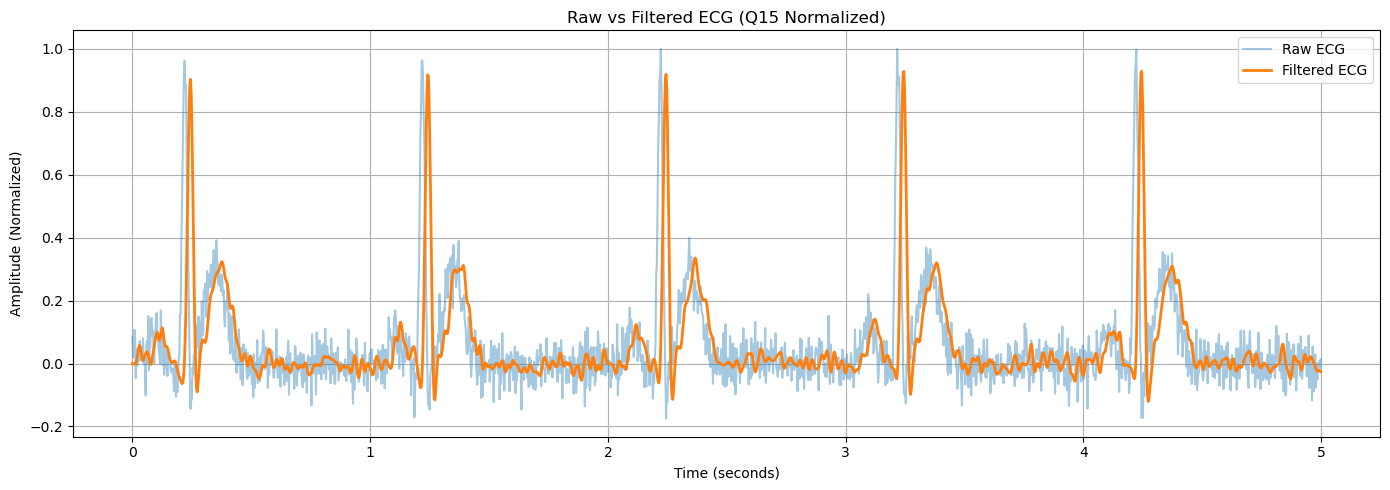

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
raw_path  = "ecg.txt"
filt_path = "ecg_filtered.txt"

# -----------------------------
# Sampling info
# -----------------------------
Fs = 360  # Hz

# -----------------------------
# Read raw ECG
# -----------------------------
with open(raw_path, "r") as f:
    raw_ecg = [int(line.strip()) for line in f if line.strip()]

# -----------------------------
# Read filtered ECG
# -----------------------------
with open(filt_path, "r") as f:
    filt_ecg = [int(line.strip()) for line in f if line.strip()]

print("Raw ECG samples     :", len(raw_ecg))
print("Filtered ECG samples:", len(filt_ecg))

# -----------------------------
# Make both signals same length
# -----------------------------
N = min(len(raw_ecg), len(filt_ecg))

raw_ecg  = np.array(raw_ecg[:N], dtype=np.int16)
filt_ecg = np.array(filt_ecg[:N], dtype=np.int16)

# -----------------------------
# Normalize Q15 -> float
# -----------------------------
raw_ecg  = raw_ecg / 32768.0
filt_ecg = filt_ecg / 32768.0

# -----------------------------
# Create time axis
# -----------------------------
t = np.arange(N) / Fs

print("Total time duration:", t[-1], "seconds")

# -----------------------------
# Plot both signals
# -----------------------------
plt.figure(figsize=(14, 5))

plt.plot(t, raw_ecg, label="Raw ECG", alpha=0.4)
plt.plot(t, filt_ecg, label="Filtered ECG", linewidth=2)

plt.title("Raw vs Filtered ECG (Q15 Normalized)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (Normalized)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
